In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Bidirectional, Masking
from tensorflow.keras.utils import to_categorical

In [3]:
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

def print_class_counts(df, title):
    print(f"\n--- Class Counts in {title} ---")
    counts = df[187].value_counts().sort_index()
    names = ['Normal', 'S-type', 'V-type', 'F-type', 'Unknown']
    for i, count in enumerate(counts):
        print(f"{names[i]} (Class {i}): {count} samples")

print_class_counts(train_df, "Original Train Data")
print_class_counts(test_df, "Original Test Data")

df_0 = train_df[train_df[187] == 0]
df_1 = train_df[train_df[187] == 1]
df_2 = train_df[train_df[187] == 2]
df_3 = train_df[train_df[187] == 3]
df_4 = train_df[train_df[187] == 4]

target_count = 20000
df_0_sampled = resample(df_0, replace=False, n_samples=target_count, random_state=42)
df_1_sampled = resample(df_1, replace=True, n_samples=target_count, random_state=42)
df_2_sampled = resample(df_2, replace=True, n_samples=target_count, random_state=42)
df_3_sampled = resample(df_3, replace=True, n_samples=target_count, random_state=42)
df_4_sampled = resample(df_4, replace=True, n_samples=target_count, random_state=42)

train_balanced = pd.concat([df_0_sampled, df_1_sampled, df_2_sampled, df_3_sampled, df_4_sampled])

print_class_counts(train_balanced, "Balanced Train Data")


--- Class Counts in Original Train Data ---
Normal (Class 0): 72471 samples
S-type (Class 1): 2223 samples
V-type (Class 2): 5788 samples
F-type (Class 3): 641 samples
Unknown (Class 4): 6431 samples

--- Class Counts in Original Test Data ---
Normal (Class 0): 18118 samples
S-type (Class 1): 556 samples
V-type (Class 2): 1448 samples
F-type (Class 3): 162 samples
Unknown (Class 4): 1608 samples

--- Class Counts in Balanced Train Data ---
Normal (Class 0): 20000 samples
S-type (Class 1): 20000 samples
V-type (Class 2): 20000 samples
F-type (Class 3): 20000 samples
Unknown (Class 4): 20000 samples


In [4]:
X_train = train_balanced.iloc[:, :-1].values.astype('float32')
y_train = train_balanced.iloc[:, -1].values.astype('int')
X_test = test_df.iloc[:, :-1].values.astype('float32')
y_test = test_df.iloc[:, -1].values.astype('int')

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"\nFinal Training Shape: {X_train.shape}")


Final Training Shape: (100000, 187, 1)


In [ ]:
def build_model(input_shape):
    inputs = Input(shape=input_shape)

    x = Masking(mask_value=0.0)(inputs)

    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = GRU(64, return_sequences=False)(x)

    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model((X_train.shape[1], 1))
model.summary()

In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=128,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


2026-02-02 10:50:42.387042: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


665/665 ━━━━━━━━━━━━━━━━━━━━ 110s 161ms/step - accuracy: 0.6644 - loss: 0.8816 - val_accuracy: 0.8165 - val_loss: 0.7301 - learning_rate: 0.0010
Epoch 2/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 113s 170ms/step - accuracy: 0.8268 - loss: 0.4929 - val_accuracy: 0.8526 - val_loss: 0.4752 - learning_rate: 0.0010
Epoch 3/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 112s 168ms/step - accuracy: 0.8716 - loss: 0.3619 - val_accuracy: 0.8899 - val_loss: 0.3261 - learning_rate: 0.0010
Epoch 4/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 116s 174ms/step - accuracy: 0.8963 - loss: 0.2967 - val_accuracy: 0.8941 - val_loss: 0.3441 - learning_rate: 0.0010
Epoch 5/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 119s 180ms/step - accuracy: 0.9105 - loss: 0.2539 - val_accuracy: 0.8977 - val_loss: 0.3401 - learning_rate: 0.0010
Epoch 6/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 121s 183ms/step - accuracy: 0.9215 - loss: 0.2234 - val_accuracy: 0.9063 - val_loss: 0.3105 - learning_rate: 0.0010
Epoch 7/30
665/665 ━━━━━━━━━━━━━━━━━━━━ 116s 174ms/step - accuracy: 0.9328 

685/685 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step

--- Final Classification Report ---
              precision    recall  f1-score   support

      Normal       0.99      0.97      0.98     18118
      S-type       0.59      0.84      0.69       556
      V-type       0.88      0.96      0.92      1448
      F-type       0.52      0.86      0.65       162
     Unknown       0.97      0.96      0.96      1608

    accuracy                           0.96     21892
   macro avg       0.79      0.92      0.84     21892
weighted avg       0.97      0.96      0.96     21892



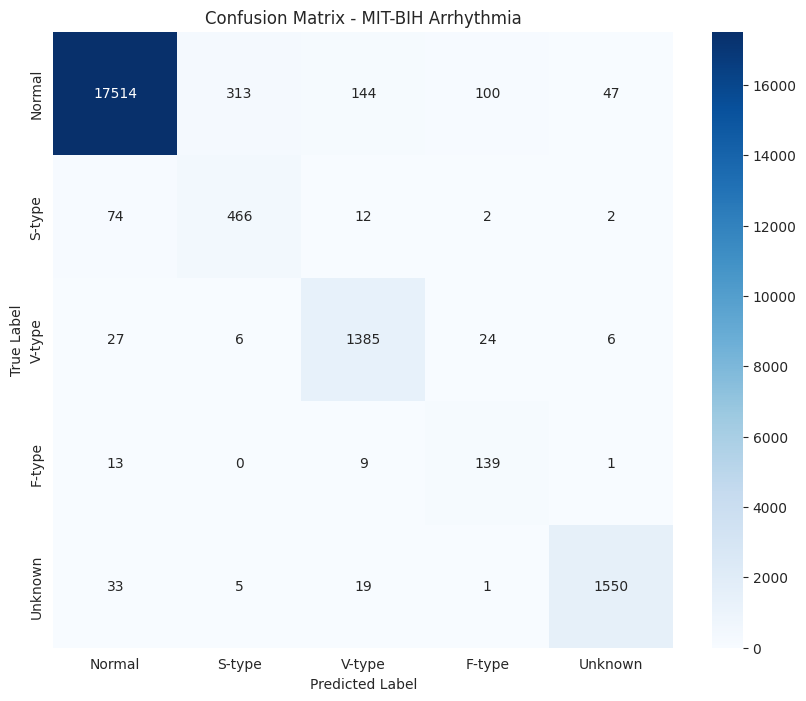

In [8]:
y_pred = np.argmax(model.predict(X_test), axis=1)
classes = ['Normal', 'S-type', 'V-type', 'F-type', 'Unknown']

print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred, target_names=classes))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - MIT-BIH Arrhythmia')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [9]:
model.save("multi_Classifier_96.h5")
print("model saved")

model saved
